Завантажуємо бібліотеки

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

Завантажуємо дані та підготовлюємо їх

In [89]:
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

merged_data = pd.merge(ratings, movies, on = 'movieId')

filtered_data = merged_data[merged_data['rating'] >= 4.0]

print(f"Rows: {filtered_data.shape[0]}")
print(f"Unique Users: {filtered_data['userId'].nunique()}")
print(f"Unique Movies: {filtered_data['movieId'].nunique()}")

Rows: 48580
Unique Users: 609
Unique Movies: 6298


Перетворимо дані у транзакційний формат

In [90]:
transaction_matrix = pd.pivot_table(filtered_data, index = 'userId', columns = 'title', values = 'rating', aggfunc = lambda x: (x >= 4.0).astype(int))

transaction_matrix = transaction_matrix.fillna(0)

print("First 5 rows:")
print(transaction_matrix.head(5))

First 5 rows:
title   '71 (2014)  'Hellboy': The Seeds of Creation (2004)  \
userId                                                        
1                0                                        0   
2                0                                        0   
3                0                                        0   
4                0                                        0   
5                0                                        0   

title   'Salem's Lot (2004)  'Til There Was You (1997)  'burbs, The (1989)  \
userId                                                                       
1                         0                          0                   0   
2                         0                          0                   0   
3                         0                          0                   0   
4                         0                          0                   0   
5                         0                          0                   0  

C:\Users\savedheart\AppData\Local\Temp\ipykernel_31456\3540644071.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  transaction_matrix = transaction_matrix.fillna(0)


Пошук частих наборів фільмів. Алгоритм Apriori - це класичний метод Data Mining для пошуку частих наборів елементів і генерації асоціативних правил у базах даних транзакцій. Він базується на принципі, що будь-яка підмножина частого набору також має бути частою. Алгоритм ідентифікує окремі елементи, що зустрічаються найчастіше, а потім розширює їх до більших наборів

In [91]:
transaction_matrix = transaction_matrix.apply(pd.to_numeric, errors = 'coerce').fillna(0).astype(bool)

min_support = 0.05
frequent_itemsets = apriori(transaction_matrix, min_support = min_support, use_colnames = True)

print(f"Number of frequent itemsets with min_support = {min_support}: {len(frequent_itemsets)}")

frequent_itemsets_sorted = frequent_itemsets.sort_values(by = 'support', ascending = False)
print(frequent_itemsets_sorted.head(10))

Number of frequent itemsets with min_support = 0.05: 33189
       support                                           itemsets
267   0.449918                 (Shawshank Redemption, The (1994))
119   0.408867                              (Forrest Gump (1994))
244   0.400657                              (Pulp Fiction (1994))
273   0.369458                 (Silence of the Lambs, The (1991))
206   0.364532                               (Matrix, The (1999))
299   0.330049        (Star Wars: Episode IV - A New Hope (1977))
115   0.293924                                (Fight Club (1999))
260   0.287356                          (Schindler's List (1993))
2228  0.275862  (Shawshank Redemption, The (1994), Forrest Gum...
300   0.275862  (Star Wars: Episode V - The Empire Strikes Bac...


Побудуємо асоціативні правила та додамо метрики

In [92]:
min_confidence = 0.5
min_lift = 1.0

rules = association_rules(frequent_itemsets, metric = "lift", min_threshold = min_lift)

filtered_rules = rules[rules['confidence'] >= min_confidence]

Відсортуємо правила за lift та виведемо топ-10

In [93]:
top_rules = filtered_rules.sort_values(by = "lift", ascending = False).head(10)

print(f"Top 10 association rules by left:")
print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Top 10 association rules by left:
                                              antecedents  \
463807  (Star Wars: Episode VI - Return of the Jedi (1...   
463826  (Star Wars: Episode V - The Empire Strikes Bac...   
463827  (Star Wars: Episode VI - Return of the Jedi (1...   
463806  (Star Wars: Episode V - The Empire Strikes Bac...   
463833  (Star Wars: Episode VI - Return of the Jedi (1...   
463800  (Star Wars: Episode V - The Empire Strikes Bac...   
463839  (Star Wars: Episode V - The Empire Strikes Bac...   
463794  (Star Wars: Episode VI - Return of the Jedi (1...   
463820  (Star Wars: Episode VI - Return of the Jedi (1...   
463821  (Star Wars: Episode VI - Return of the Jedi (1...   

                                              consequents   support  \
463807  (Star Wars: Episode V - The Empire Strikes Bac...  0.052545   
463826  (Star Wars: Episode VI - Return of the Jedi (1...  0.052545   
463827  (Star Wars: Episode V - The Empire Strikes Bac...  0.052545   
463806  (S

Інтерпретація кількох правил

In [94]:
print("Interpretation of some rules:")
for index, row in top_rules.iterrows():
    print(f"\nRule: {row['antecedents']} -> {row['consequents']}")
    print(f"Support: {row['support']:.4f}, Confidence: {row['confidence']:.4f}, Lift: {row['lift']:.4f}")

Interpretation of some rules:

Rule: frozenset({'Star Wars: Episode VI - Return of the Jedi (1983)', 'Kill Bill: Vol. 2 (2004)', 'Matrix, The (1999)'}) -> frozenset({'Star Wars: Episode V - The Empire Strikes Back (1980)', 'Kill Bill: Vol. 1 (2003)', 'Star Wars: Episode IV - A New Hope (1977)'})
Support: 0.0525, Confidence: 0.8889, Lift: 13.2033

Rule: frozenset({'Star Wars: Episode V - The Empire Strikes Back (1980)', 'Kill Bill: Vol. 1 (2003)', 'Star Wars: Episode IV - A New Hope (1977)'}) -> frozenset({'Star Wars: Episode VI - Return of the Jedi (1983)', 'Kill Bill: Vol. 2 (2004)', 'Matrix, The (1999)'})
Support: 0.0525, Confidence: 0.7805, Lift: 13.2033

Rule: frozenset({'Star Wars: Episode VI - Return of the Jedi (1983)', 'Kill Bill: Vol. 2 (2004)'}) -> frozenset({'Star Wars: Episode V - The Empire Strikes Back (1980)', 'Star Wars: Episode IV - A New Hope (1977)', 'Matrix, The (1999)', 'Kill Bill: Vol. 1 (2003)'})
Support: 0.0525, Confidence: 0.7805, Lift: 12.8464

Rule: frozenset

Побудуємо графік Support vs Confidence

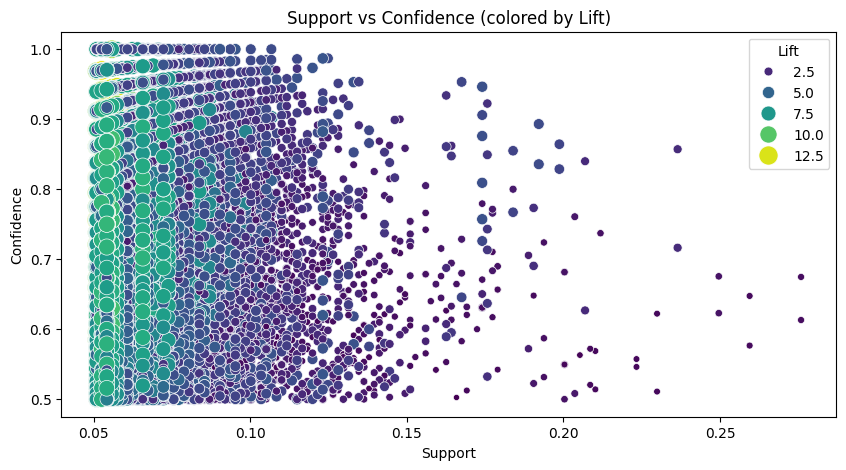

In [95]:
plt.figure(figsize = (10, 5))
sns.scatterplot(data = filtered_rules, x = "support", y = "confidence", hue = "lift", palette = "viridis", size = 'lift', sizes = (20, 200))
plt.title("Support vs Confidence (colored by Lift)")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.legend(title = "Lift")
plt.show()

Побудуємо графік Lift vs Confidence

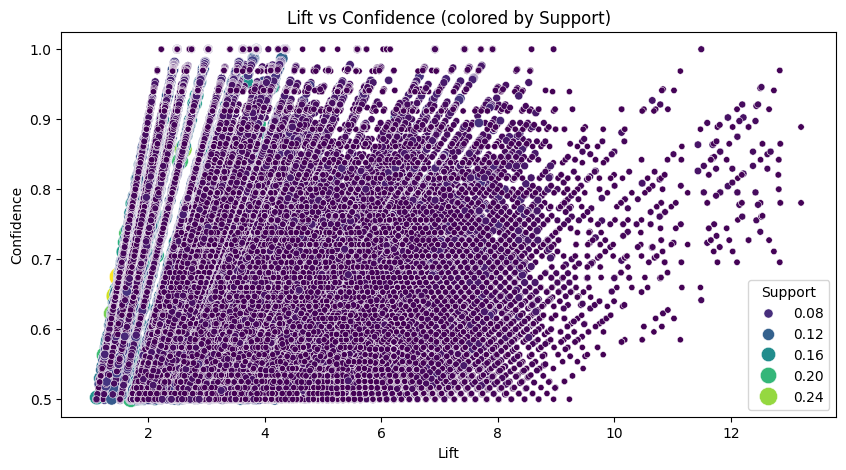

In [96]:
plt.figure(figsize = (10, 5))
sns.scatterplot(data = filtered_rules, x = "lift", y = "confidence", hue = "support", palette = "viridis", size = 'support', sizes = (20, 200))
plt.title("Lift vs Confidence (colored by Support)")
plt.xlabel("Lift")
plt.ylabel("Confidence")
plt.legend(title = "Support")
plt.show()

Оцінимо вплив min_support і min_confidence на кількість і якість знайдених правил та побудуємо графіки
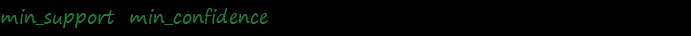

|   min_support |   min_confidence |   num_rules |   average_support |   average_confidence |   average_lift |
|--------------:|-----------------:|------------:|------------------:|---------------------:|---------------:|
|          0.05 |             0.5  |      219965 |         0.0577148 |             0.692682 |        3.70357 |
|          0.05 |             0.55 |      184560 |         0.0577124 |             0.725344 |        3.65925 |
|          0.05 |             0.6  |      153038 |         0.0577396 |             0.75657  |        3.59884 |
|          0.05 |             0.65 |      123445 |         0.0577268 |             0.788287 |        3.53425 |
|          0.05 |             0.7  |       97697 |         0.0576429 |             0.818377 |        3.47362 |
|          0.1  |             0.5  |        1652 |         0.117999  |             0.680645 |        2.41498 |
|          0.1  |             0.55 |        1369 |         0.117748  |             0.713065 |        2.44795 |
|

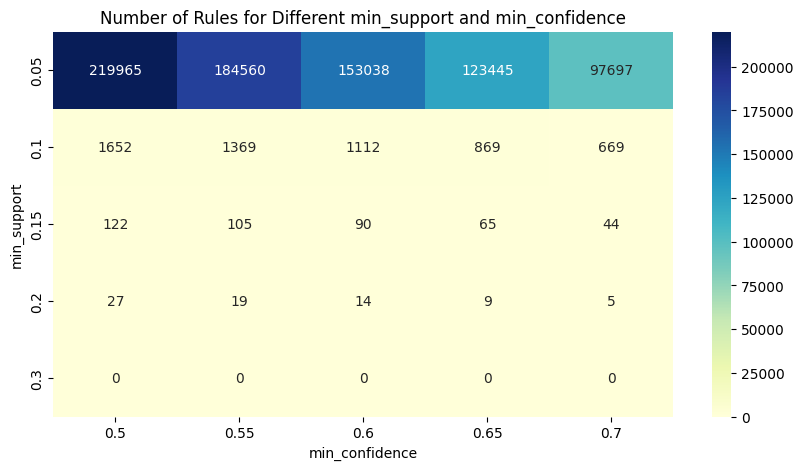

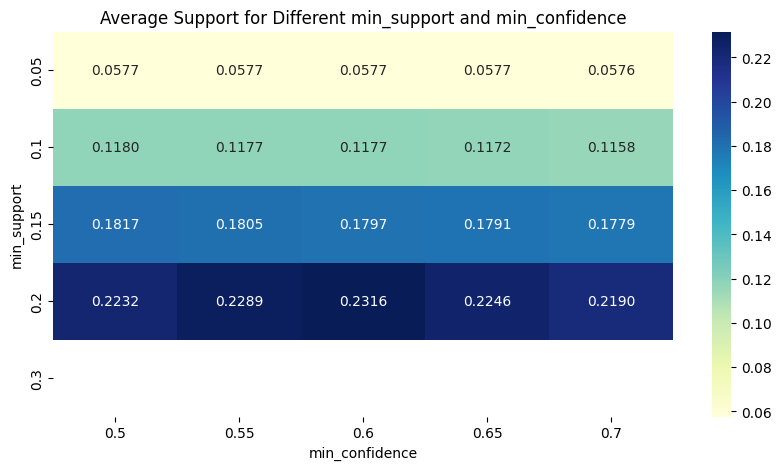

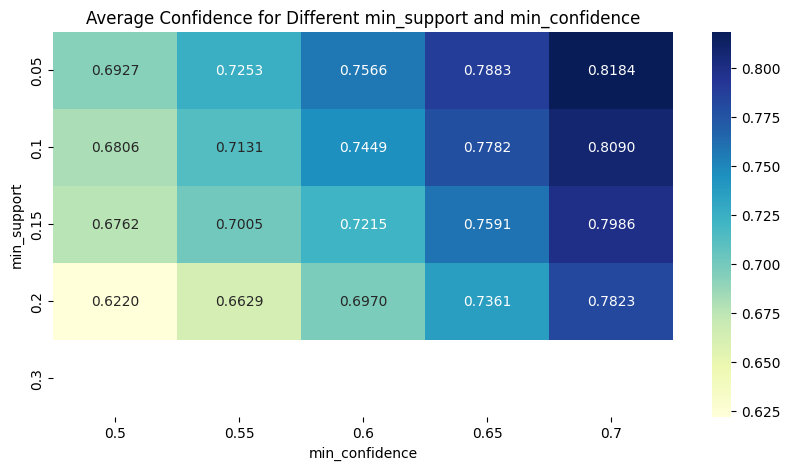

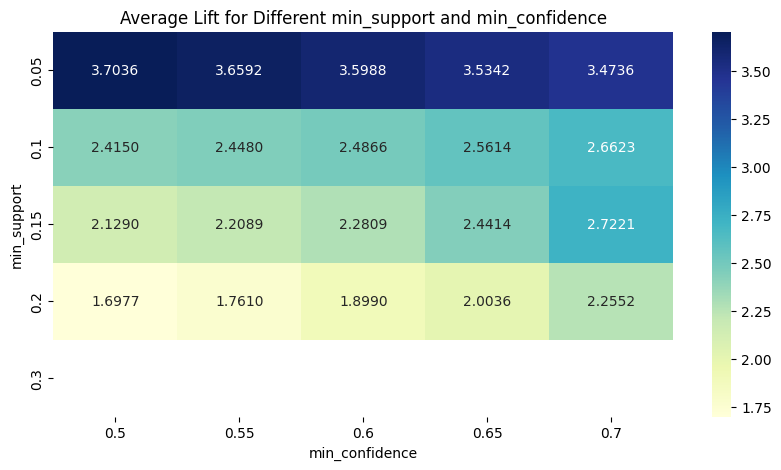

In [99]:
min_support_values = [0.05, 0.1, 0.15, 0.2, 0.3]
min_confidence_values = [0.5, 0.55, 0.6, 0.65, 0.7]

results = []

for support in min_support_values:
    for confidence in min_confidence_values:

        frequent_itemsets = apriori(transaction_matrix, min_support = support, use_colnames = True)

        rules = association_rules(frequent_itemsets, metric = "lift", min_threshold = 1.0)

        filtered_rules = rules[rules['confidence'] >= confidence]

        results.append({
            'min_support': support,
            'min_confidence': confidence,
            'num_rules': len(filtered_rules),
            'average_support': filtered_rules['support'].mean(),
            'average_confidence': filtered_rules['confidence'].mean(),
            'average_lift': filtered_rules['lift'].mean()
        })

results_df = pd.DataFrame(results)
print(results_df.to_markdown(index = False))

plt.figure(figsize = (10, 5))
sns.heatmap(results_df.pivot(index='min_support', columns='min_confidence', values='num_rules'), annot = True, cmap = "YlGnBu", fmt = 'g')
plt.title("Number of Rules for Different min_support and min_confidence")
plt.xlabel("min_confidence")
plt.ylabel("min_support")
plt.show()

plt.figure(figsize = (10, 5))
sns.heatmap(results_df.pivot(index='min_support', columns='min_confidence', values='average_support'), annot = True, cmap = "YlGnBu", fmt = '.4f')
plt.title("Average Support for Different min_support and min_confidence")
plt.xlabel("min_confidence")
plt.ylabel("min_support")
plt.show()

plt.figure(figsize = (10, 5))
sns.heatmap(results_df.pivot(index='min_support', columns='min_confidence', values='average_confidence'), annot = True, cmap = "YlGnBu", fmt = '.4f')
plt.title("Average Confidence for Different min_support and min_confidence")
plt.xlabel("min_confidence")
plt.ylabel("min_support")
plt.show()

plt.figure(figsize = (10, 5))
sns.heatmap(results_df.pivot(index='min_support', columns='min_confidence', values='average_lift'), annot = True, cmap = "YlGnBu", fmt = '.4f')
plt.title("Average Lift for Different min_support and min_confidence")
plt.xlabel("min_confidence")
plt.ylabel("min_support")
plt.show()

ВИСНОВКИ
Асоціативні правила використовуються для персоналізованих рекомендацій: якщо користувач оцінив фільм A, система рекомендує фільм B, який часто оцінюється разом з A. Метрика support дозволяє визначити, наскільки популярним є це правило серед користувачів, confidence показує ймовірність того, що якщо користувач оцінив один фільм, то він оцінить і інший, та lift допомагає зрозуміти, наскільки сильна асоціація між двома фільмами, порівняно з випадковими поєднаннями.
Вищий min_support зменшує кількість правил, але підвищує їх якість. Вищий min_confidence також зменшує кількість правил, роблячи їх більш надійними. Нижчі пороги дають більше правил, але з меншою надійністю.